In [1]:
#!pip install catboost

In [2]:
# Importing all necessary libraries and classes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold, RandomizedSearchCV
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNetCV
from sklearn.ensemble import (RandomForestRegressor, BaggingRegressor, AdaBoostRegressor,
                               GradientBoostingRegressor)
from sklearn import metrics
from catboost import CatBoostRegressor
import lightgbm as lgb 

np.random.seed(11)


In [3]:
# Handling compatibility: scikit-learn 1.6+ looks for a __sklearn_tags__ method that CatBoost doesn't provide yet, which crashes it inside cross_val_score, RandomizedSearchCV, etc.
# Here is to handling that issue in advance

if not hasattr(CatBoostRegressor, "__sklearn_tags__"):
    from sklearn.utils._tags import Tags, TargetTags, RegressorTags, InputTags

    def _catboost_sklearn_tags(self):
        return Tags(
            estimator_type="regressor",
            target_tags=TargetTags(required=True),
            transformer_tags=None,
            classifier_tags=None,
            regressor_tags=RegressorTags(),
            input_tags=InputTags(allow_nan=True, sparse=True),
        )

    CatBoostRegressor.__sklearn_tags__ = _catboost_sklearn_tags

# Compatibility patch: CatBoost copies the cat_features list internally, which fails
# sklearn's strict clone() identity check whenever cat_features is set.
if not hasattr(CatBoostRegressor, "__sklearn_clone__"):
    def _catboost_sklearn_clone(self):
        return self.__class__(**self.get_params(deep=False))
    CatBoostRegressor.__sklearn_clone__ = _catboost_sklearn_clone

In [4]:
# Reading in the datasets

data = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
submission = pd.read_csv("sample_submission.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

## Exploratory Data Analysis

In [ ]:
# Inspecting the train data

data.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [ ]:
test.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format
0,row_00009,PRD-2WLNC8,8.628,Low Fat,0.0167,household,190.72,STORE-HL7,23,Medium,Tier_3,Superstore
1,row_00015,PRD-LV9PLM,6.993,Low Fat,0.0579,Health and Hygiene,261.07,STORE-9RG,28,Small,Tier_2,Standard Supermarket
2,row_00019,PRD-ET6ZI7,NaN,Low Fat,0.1262,FRUITS AND VEGETABLES,112.50,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket
3,row_00020,PRD-6RX35U,14.034,Regular,0.0761,frozen foods,200.71,STORE-DKU,30,NaN,Tier_2,Standard Supermarket
4,row_00023,PRD-I4J38V,13.063,Low Fat,0.0650,Frozen Foods,150.59,STORE-89Z,33,Medium,Tier_1,Standard Supermarket


Both tables share the same 12 feature columns (`id`, `product_code`, `product_weight_kg`, `fat_content`, `shelf_visibility`, `product_category`, `product_price`, `store_code`, `store_age_years`, `store_size`, `store_location_tier`, `store_format`); only `train.csv` additionally has `total_sales`, which is what we are predicting.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [ ]:
data.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


In [ ]:
data.describe(include="object")

,id,product_code,fat_content,product_category,store_code,store_size,store_location_tier,store_format
count,6818,6818,6818,6818,6818,4899,6818,6818
unique,6818,1555,2,48,10,3,3,4
top,row_08522,PRD-YZB4K8,Low Fat,Fruits and Vegetables,STORE-YLW,Medium,Tier_3,Standard Supermarket
freq,1,9,4425,480,754,2218,2677,4462


**Key takeaways:** 6,818 rows. Missing values in `product_weight_kg` (1,225) and `store_size` (1,919), nothing else. `total_sales` is right-skewed (mean 2,175 & median 1,791), so the model will train on `log1p(total_sales)`. Also, `product_category` has 48 raw values that collapse to 16 as soon as the casing was addressed.

In [ ]:
data.isnull().sum()  # exact missing-value count per column


Text(0.5, 1.0, 'Missing Values')

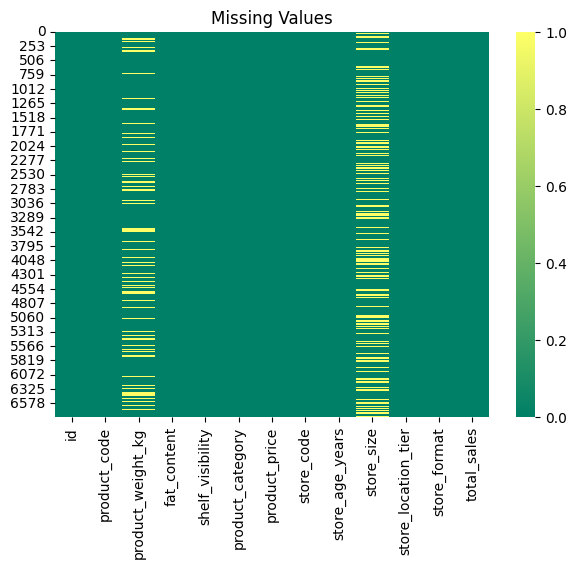

In [ ]:
plt.figure(figsize=(7, 5))
sns.heatmap(data.isnull(), cmap='summer')
plt.title("Missing Values")


Missing at Random: the missing values in `product_weight_kg` and `store_size` are scattered across rows rather than concentrated in a block, so there is no obvious pattern (like one store never reporting weight) that would need special handling beyond a simple fill.

<Axes: title={'center': 'product_weight_kg'}>

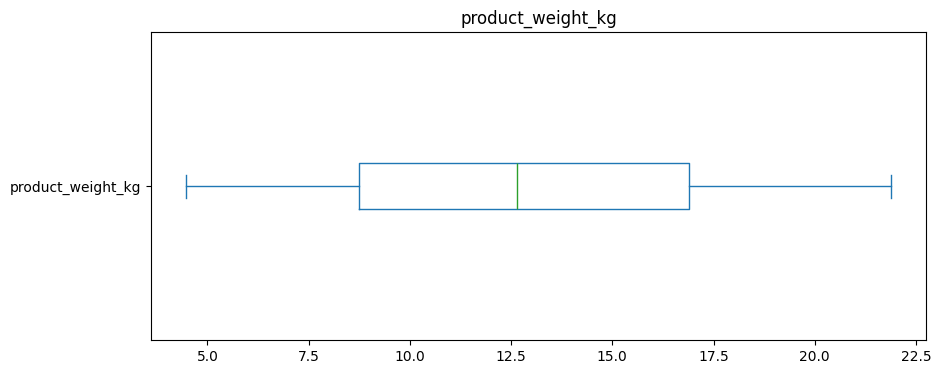

In [ ]:
data.product_weight_kg.plot(kind='box', vert=False, figsize=(10, 4), title="product_weight_kg")


No outliers in `product_weight_kg`, so a mean fill is safe.

In [ ]:
# Capturing train stats now so test gets the SAME values later, to avoid leakage from test's own mean/mode

weight_mean = data.product_weight_kg.mean()
size_mode = data.store_size.mode()[0]

data.product_weight_kg = data.product_weight_kg.fillna(weight_mean)
data.store_size = data.store_size.fillna(size_mode)
data.isnull().sum()

,0
id,0
product_code,0
product_weight_kg,0
fat_content,0
shelf_visibility,0
product_category,0
product_price,0
store_code,0
store_age_years,0
store_size,0


<Axes: >

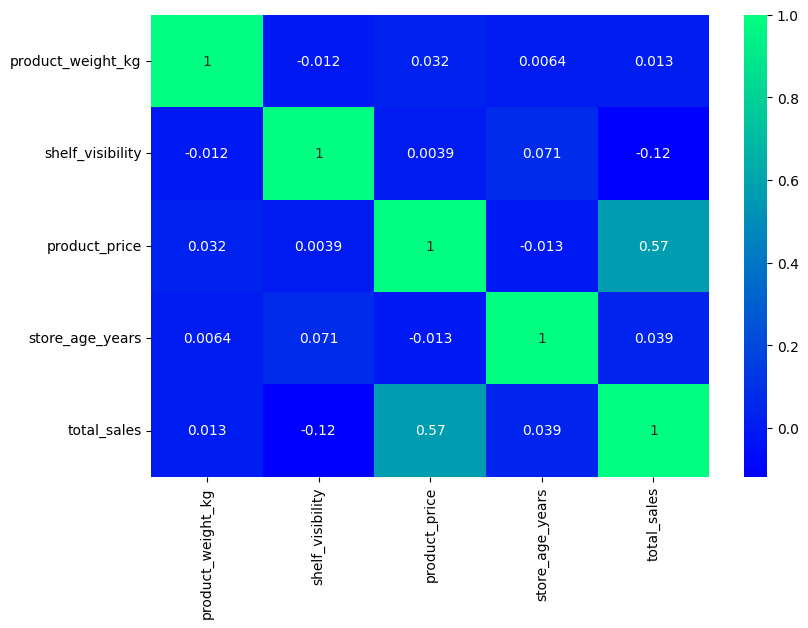

In [ ]:
plt.figure(figsize=(9, 6))
sns.heatmap(data.select_dtypes(['float', 'int']).corr(), annot=True, cmap="winter")


There seem to be moderate correlation between the target and the predictors, with no sign of multicollinearity

In [ ]:
# Plotting for distributions
sns.pairplot(data=data)  

In [ ]:
dfr

<Axes: title={'center': 'total_sales (confirms the right-skew)'}>

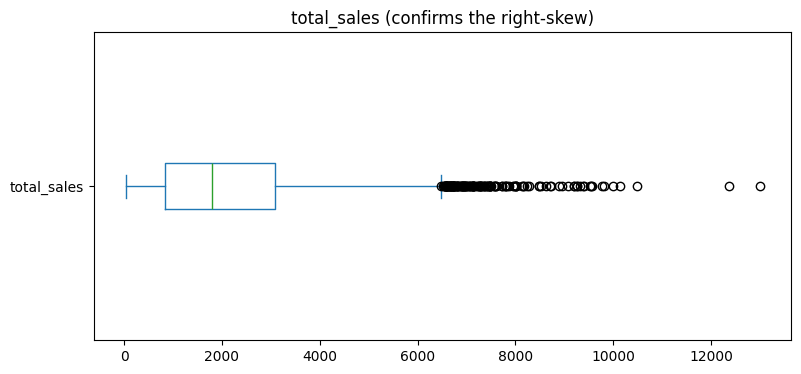

In [ ]:
data['total_sales'].plot(kind='box', vert=False, figsize=(9, 4), title="total_sales (confirms the right-skew)")


<Axes: title={'center': 'fat_content'}, xlabel='fat_content'>

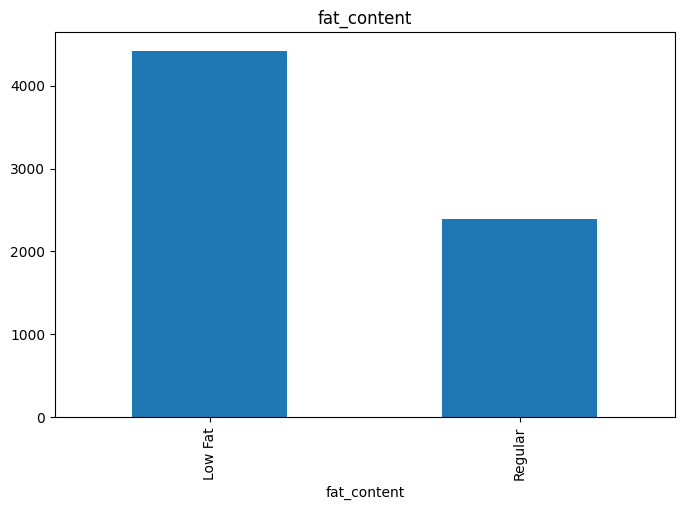

In [ ]:
data['fat_content'].value_counts().plot(kind='bar', figsize=(8, 5), title="fat_content")


In [ ]:
# Store x category combos — the biggest ones motivate the target encoding step further down
(data.groupby(['store_code', 'product_category'])['total_sales']
     .sum().sort_values(ascending=False).head(10))


store_code  product_category     
STORE-7WS   Snack Foods              217044.14
            Fruits and Vegetables    193352.21
            Household                163011.87
STORE-9RG   Snack Foods              154259.56
STORE-7WS   FRUITS AND VEGETABLES    145740.09
STORE-9RG   Fruits and Vegetables    144725.42
STORE-YLW   Fruits and Vegetables    129779.80
STORE-AGY   Snack Foods              128702.30
STORE-89Z   Fruits and Vegetables    128631.48
STORE-7WS   fruits and vegetables    127391.23
Name: total_sales, dtype: float64

`STORE-7WS` + Snack Foods is the single highest-selling combination, and `STORE-7WS` repeats near the top with several categories, a real store x category effect worth encoding explicitly later.

In [ ]:
print("Unique categories before cleanup:", data.product_category.nunique())
data['product_category'] = data['product_category'].astype(str).str.capitalize()
test['product_category'] = test['product_category'].astype(str).str.capitalize()
print("Unique categories after cleanup:", data.product_category.nunique())


Unique categories before cleanup: 48
Unique categories after cleanup: 16


48 raw values were really the same 16 categories written with inconsistent casing (`Snack Foods`, `SNACK FOODS`, `snack foods`, ...).

## Cleaning, Feature Engineering, and Target Encoding

Everything below uses statistics learned from `data` (train) only, then applies the exact same values to `test`, so nothing from the test set leaks into the pipeline.

In [ ]:
# Fill test with train's stats (not test's own), same as we did for train above
test['product_weight_kg'] = test['product_weight_kg'].fillna(weight_mean)
test['store_size'] = test['store_size'].fillna(size_mode)

# shelf_visibility == 0 almost always means "not recorded", not "invisible" — treat as missing
data.loc[data['shelf_visibility'] == 0, 'shelf_visibility'] = np.nan
test.loc[test['shelf_visibility'] == 0, 'shelf_visibility'] = np.nan

visibility_by_category = data.groupby('product_category')['shelf_visibility'].median()
overall_visibility_median = data['shelf_visibility'].median()

def fill_visibility(df):
    return (df['shelf_visibility']
            .fillna(df['product_category'].map(visibility_by_category))
            .fillna(overall_visibility_median))

data['shelf_visibility'] = fill_visibility(data)
test['shelf_visibility'] = fill_visibility(test)

print("Remaining missing values -> train:", data.isnull().sum().sum(), " test:", test.isnull().sum().sum())


Remaining missing values -> train: 0  test: 0


In [ ]:
# price_per_kg: normalizes price by weight. store_age_bucket: coarser signal than raw years.
data['price_per_kg'] = data['product_price'] / data['product_weight_kg']
test['price_per_kg'] = test['product_price'] / test['product_weight_kg']

q1, q2 = data['store_age_years'].quantile([1/3, 2/3])
bin_edges, bin_labels = [-np.inf, q1, q2, np.inf], ['New', 'Mid', 'Old']
data['store_age_bucket'] = pd.cut(data['store_age_years'], bins=bin_edges, labels=bin_labels)
test['store_age_bucket'] = pd.cut(test['store_age_years'], bins=bin_edges, labels=bin_labels)


**Target (mean) encoding:** one-hot encoding lets each store and each category vote separately, it can't easily express "this store is unusually good at this category." This adds three columns with the average `total_sales` for a row's store, its category, and that exact store/category pairing, smoothed toward the overall average so rare combos don't just memorize one row. Train values are computed out-of-fold (never from a row's own target) to avoid leakage; test uses the encoding learned from all of train.

In [ ]:
def add_target_encoding(train_df, test_df, group_cols, target_col='total_sales', n_splits=5, smoothing=10):
    feature_name = '_'.join(group_cols) + '_target_enc'
    global_mean = train_df[target_col].mean()

    oof = pd.Series(index=train_df.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=11)
    for tr_idx, val_idx in kf.split(train_df):
        stats = train_df.iloc[tr_idx].groupby(group_cols)[target_col].agg(['mean', 'count'])
        stats['smoothed'] = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        mapped = train_df.iloc[val_idx].merge(stats['smoothed'], left_on=group_cols, right_index=True, how='left')['smoothed']
        oof.iloc[val_idx] = mapped.fillna(global_mean).values
    train_df[feature_name] = oof

    full_stats = train_df.groupby(group_cols)[target_col].agg(['mean', 'count'])
    full_stats['smoothed'] = (full_stats['mean'] * full_stats['count'] + global_mean * smoothing) / (full_stats['count'] + smoothing)
    test_df = test_df.merge(full_stats['smoothed'].rename(feature_name), left_on=group_cols, right_index=True, how='left')
    test_df[feature_name] = test_df[feature_name].fillna(global_mean)
    return train_df, test_df

data, test = add_target_encoding(data, test, ['store_code'])
data, test = add_target_encoding(data, test, ['product_category'])
data, test = add_target_encoding(data, test, ['store_code', 'product_category'])


## One-Hot Encoding

`LabelEncoder` implies a fake order between categories (`Regular` = 1 does not mean "more" than `Low Fat` = 0). One-hot with `drop_first=True` avoids that, and avoids perfect multicollinearity for the linear models.

In [ ]:
categorical_cols = ['fat_content', 'product_category', 'store_code', 'store_size',
                    'store_location_tier', 'store_format', 'store_age_bucket']

data_encoded = pd.get_dummies(data, columns=categorical_cols, drop_first=True)
test_encoded = pd.get_dummies(test, columns=categorical_cols, drop_first=True)
test_ids = test['id']

train_feature_cols = data_encoded.drop(['id', 'product_code', 'total_sales'], axis=1).columns
test_encoded = test_encoded.reindex(columns=train_feature_cols, fill_value=0)  # align test to train's exact columns


## Model Development

In [ ]:
X = data_encoded[train_feature_cols]
y = data_encoded['total_sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

# Scale AFTER the split, fit only on train — scaling before the split (or fit on all of X) leaks test info
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)


`total_sales` is right-skewed, so every model is wrapped in `TransformedTargetRegressor`: it fits on `log1p(total_sales)` and auto-inverts predictions with `expm1`. `rmse_holdout` checks the single 80/20 split; `rmse_cv` averages over 5 folds and is the more trustworthy number for comparing models (it tracks the real leaderboard score far more closely than any single holdout split does).

In [ ]:
def wrap_log_target(model):
    return TransformedTargetRegressor(regressor=model, func=np.log1p, inverse_func=np.expm1)

def rmse_holdout(model, Xtr=None, Xte=None):
    Xtr = X_train_scaled if Xtr is None else Xtr
    Xte = X_test_scaled if Xte is None else Xte
    wrapped = wrap_log_target(model)
    wrapped.fit(Xtr, y_train)
    return np.sqrt(metrics.mean_squared_error(y_test, wrapped.predict(Xte)))

def rmse_cv(model, X=None, cv=5):
    X = X_train_scaled if X is None else X
    kfold = KFold(n_splits=cv, shuffle=True, random_state=11)
    scores = cross_val_score(wrap_log_target(model), X, y_train, scoring='neg_root_mean_squared_error', cv=kfold)
    return -scores.mean(), scores.std()


### Baseline Model Comparison (Cross-Validated RMSE)

`ElasticNetCV` and `LightGBM` are included here as extra baselines. Only Gradient Boosting and CatBoost get tuned further below, since those two are the models that have shown the strongest results throughout this project, if either ElasticNetCV or LightGBM comes out on top here, they're worth tuning the same way.

In [ ]:
candidate_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "ElasticNetCV": ElasticNetCV(cv=5, random_state=11),  # linear model that picks its own L1/L2 mix and regularization strength
    "Random Forest": RandomForestRegressor(random_state=11),
    "AdaBoost": AdaBoostRegressor(random_state=11),
    "Bagging": BaggingRegressor(random_state=11),
    "Gradient Boosting": GradientBoostingRegressor(random_state=11),
    "LightGBM": lgb.LGBMRegressor(random_state=11, verbose=-1),
    "CatBoost": CatBoostRegressor(random_state=11, learning_rate=.02, verbose=False),
}

results = [{"model": name, "cv_rmse_mean": (r := rmse_cv(m))[0], "cv_rmse_std": r[1]}
           for name, m in candidate_models.items()]
results_df = pd.DataFrame(results).sort_values("cv_rmse_mean").reset_index(drop=True)
results_df


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.188e+00, tolerance: 4.627e-01
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.944e+00, tolerance: 4.613e-01
  model = cd_fast.enet_coordinate_descent(


,model,cv_rmse_mean,cv_rmse_std
0,Gradient Boosting,1126.006683,32.263851
1,CatBoost,1126.008976,29.439433
2,LightGBM,1146.390499,30.762975
3,Ridge,1151.301968,47.834884
4,Linear Regression,1151.360810,48.120735
5,ElasticNetCV,1152.925633,48.755122
6,Random Forest,1168.328051,14.568272
7,Bagging,1217.322323,10.574158
8,AdaBoost,1381.734480,57.163363


### Tuning Gradient Boosting and CatBoost

`RandomizedSearchCV` instead of a full grid search, to stay fast enough for a hackathon deadline. Widen `param_distributions` if you have spare time.

In [ ]:
gb_param_dist = {
    "n_estimators": [200, 400, 600, 800], "max_depth": [2, 3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1], "subsample": [0.7, 0.85, 1.0],
}
gb_search = RandomizedSearchCV(GradientBoostingRegressor(random_state=11), gb_param_dist,
                                n_iter=25, scoring="neg_root_mean_squared_error", cv=5, random_state=11, n_jobs=-1)
gb_search.fit(X_train_scaled, np.log1p(y_train))
best_gb = GradientBoostingRegressor(random_state=11, **gb_search.best_params_)
print("Best GB params:", gb_search.best_params_, " | holdout RMSE:", rmse_holdout(best_gb))


Best GB params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.05}  | holdout RMSE: 1054.4954453187743


In [ ]:
cat_param_dist = {
    "depth": [4, 6, 8, 10], "learning_rate": [0.01, 0.02, 0.05, 0.1],
    "iterations": [500, 800, 1200], "l2_leaf_reg": [1, 3, 5, 7],
}
cat_search = RandomizedSearchCV(CatBoostRegressor(random_state=11, verbose=False), cat_param_dist,
                                 n_iter=20, scoring="neg_root_mean_squared_error", cv=5, random_state=11,
                                 n_jobs=1)  # n_jobs=1: the CatBoost tag patch above doesn't reach separate worker processes
cat_search.fit(X_train_scaled, np.log1p(y_train))
best_cat = CatBoostRegressor(random_state=11, verbose=False, **cat_search.best_params_)
print("Best CatBoost params:", cat_search.best_params_, " | holdout RMSE:", rmse_holdout(best_cat))


Best CatBoost params: {'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 800, 'depth': 8}  | holdout RMSE: 1049.7628146265306


### CatBoost with Native Categorical Handling

CatBoost can learn directly from raw category values (no one-hot, no scaling), which is often stronger for interaction-heavy features like store x category. This reuses the hyperparameters just tuned above, applied to the raw columns instead of the one-hot/scaled ones. Same train/test split (same `random_state`, same row order), so the comparison to `best_cat` above is fair.

In [ ]:
raw_cols = [c for c in data.columns if c not in ['id', 'product_code', 'total_sales']]
X_raw = data[raw_cols].copy()
test_raw = test[raw_cols].copy()
for col in categorical_cols:
    X_raw[col] = X_raw[col].astype(str)
    test_raw[col] = test_raw[col].astype(str)
cat_feature_idx = [X_raw.columns.get_loc(c) for c in categorical_cols]

X_raw_train, X_raw_test, _, _ = train_test_split(X_raw, y, test_size=0.2, random_state=11)  # identical split to X_train/X_test

best_cat_native = CatBoostRegressor(random_state=11, verbose=False, cat_features=cat_feature_idx, **cat_search.best_params_)
native_holdout_rmse = rmse_holdout(best_cat_native, Xtr=X_raw_train, Xte=X_raw_test)
native_cv_mean, native_cv_std = rmse_cv(best_cat_native, X=X_raw_train)
print(f"Native-categorical CatBoost -> holdout: {native_holdout_rmse:.2f}, CV: {native_cv_mean:.2f} (+/- {native_cv_std:.2f})")


Native-categorical CatBoost -> holdout: 1055.30, CV: 1122.53 (+/- 34.58)


### Comparing Everything on CV (the Number That Matters)

In [ ]:
tuned_gb_cv_mean, tuned_gb_cv_std = rmse_cv(best_gb)
tuned_cat_cv_mean, tuned_cat_cv_std = rmse_cv(best_cat)

comparison = pd.DataFrame([
    {"model": "Tuned Gradient Boosting", "cv_rmse": tuned_gb_cv_mean, "cv_std": tuned_gb_cv_std},
    {"model": "Tuned CatBoost (one-hot)", "cv_rmse": tuned_cat_cv_mean, "cv_std": tuned_cat_cv_std},
    {"model": "Tuned CatBoost (native categorical)", "cv_rmse": native_cv_mean, "cv_std": native_cv_std},
]).sort_values("cv_rmse").reset_index(drop=True)
comparison


,model,cv_rmse,cv_std
0,Tuned CatBoost (one-hot),1122.207623,30.808885
1,Tuned CatBoost (native categorical),1122.533860,34.576720
2,Tuned Gradient Boosting,1123.537279,33.829204


### Weighted Blend (Gradient Boosting + CatBoost)

A plain weighted average of the two strongest models, searched from 0% to 100% GB weight in 1% steps on the holdout split. Simpler than a stacked meta-model, and often just as good with only two strong base models.

In [ ]:
pred_gb = wrap_log_target(best_gb).fit(X_train_scaled, y_train).predict(X_test_scaled)
pred_cat = wrap_log_target(best_cat).fit(X_train_scaled, y_train).predict(X_test_scaled)

weights = np.linspace(0, 1, 101)
blend_rmses = [np.sqrt(metrics.mean_squared_error(y_test, w * pred_gb + (1 - w) * pred_cat)) for w in weights]
best_blend_weight = weights[np.argmin(blend_rmses)]
print(f"Best GB weight: {best_blend_weight:.2f} | Blend holdout RMSE: {min(blend_rmses):.2f}")


Best GB weight: 0.19 | Blend holdout RMSE: 1049.49


## Final Model and Submission

Pick `final_choice` based on the **CV** numbers above (`"gb"`, `"cat"`, `"cat_native"`, or `"blend"`), not the holdout numbers, CV tracks the real leaderboard score far more closely.

In [ ]:
final_choice = "cat"  # change based on the CV comparison table above

final_scaler = StandardScaler()
X_full_scaled = pd.DataFrame(final_scaler.fit_transform(X), columns=X.columns, index=X.index)
test_scaled = pd.DataFrame(final_scaler.transform(test_encoded), columns=test_encoded.columns, index=test_encoded.index)

if final_choice == "cat_native":
    final_model = wrap_log_target(CatBoostRegressor(random_state=11, verbose=False, cat_features=cat_feature_idx, **cat_search.best_params_))
    final_model.fit(X_raw, y)
    test_predictions = final_model.predict(test_raw)
elif final_choice == "blend":
    gb_full = wrap_log_target(best_gb).fit(X_full_scaled, y)
    cat_full = wrap_log_target(best_cat).fit(X_full_scaled, y)
    test_predictions = best_blend_weight * gb_full.predict(test_scaled) + (1 - best_blend_weight) * cat_full.predict(test_scaled)
else:
    final_candidates = {"gb": best_gb, "cat": best_cat}
    final_model = wrap_log_target(final_candidates[final_choice])
    final_model.fit(X_full_scaled, y)
    test_predictions = final_model.predict(test_scaled)


In [ ]:
print(submission.head())  # confirm the expected column names before saving


          id  total_sales
0  row_00009      2174.76
1  row_00015      2174.76
2  row_00019      2174.76
3  row_00020      2174.76
4  row_00023      2174.76


In [ ]:
submission_out = pd.DataFrame({"id": test_ids, "total_sales": test_predictions})  # rename columns here if submission.head() looked different
submission_out.to_csv("SDQ DSN-Mart Submission.csv", index=False)
submission_out.head()


,id,total_sales
0,row_00009,2376.892134
1,row_00015,3619.369994
2,row_00019,2939.474016
3,row_00020,2968.450711
4,row_00023,2280.094923
